Import all necessary python libraries.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
import os
from pathlib import Path
import numpy as np
import itertools
import seaborn as sns

# background of the experiment


We have recorded flow cytometry data for several strains.

In all cases, we removed the old carbon source, and cells were shifted to galactose growth (either 2 or 0.2%) at the start of the experiment.

So we are expecting that they will start to express genes in the gal cluster to make use of the new carbon source.

Two strains carry either the Gal1p (YET911) or DOA1p (YET937) tagged with mScarlet.

This means, that when the cells induce the expression of GAL1, they will also start producing mScalet.

The mScarlet we can see as an increase in fluorescence.

We also included the YET938 strain, DOA1 tagged with mScarlet under the GAL1 promoter.

The last strain is the WT strain (untagged; YET181). 

![title](imgs/SC_practical_flowcytometry.png)

# Now, let's look at the data

The flow cytometer data have been exported as .csv files

In [ ]:
paths = [
   Path('practical data','GLu or RAAF pregrown_0.2GAL induction_911_937_938_timepoints(min)').glob('*.csv'),
   Path('practical data','GLu or RAAF pregrown_2GAL induction_911_937_938_timepoints(min)').glob('*.csv'),
]

#select one of the induction experiments
i = 0

files=sorted(paths[i])

# show example naming format
Path(files[2]).stem

'911_2GLU2GAL_T120'

Now let's load the data in a gigantic dataframe.

In [4]:
dfs = []
for file in files:

    #get meta-data from filename for two induction experiments
    strain, transition, time = Path(file).stem.split('_')
    time = float(time[1:])

    #load data in pandas dataframe and add meta-data to frame
    df=pd.read_csv(file)
    
    df['strain']=strain
    df['transition']=transition
    df['time']=time
    dfs.append(df)
    
comb_df=pd.concat(dfs).reset_index(drop=True)
comb_df = comb_df[comb_df.columns[1:]]

In [5]:
comb_df.head()

,FSC-H,FSC-A,SSC-H,SSC-A,GFP-488nm-H,GFP-488nm-A,Red-488nm-H,Red-488nm-A,CFP-405nm-H,CFP-405nm-A,...,RFP-405nm-A,RFP-561nm-H,RFP-561nm-A,FarRed-561nm-H,FarRed-561nm-A,FSC-Width,Time,strain,transition,time
0,413793.4,442569.7,351497.3,349336.2,1550.2,1208.7,631.9,497.1,372.4,100.8,...,943.6,288.9,-12.6,341.3,291.2,1095.2150,0.0,911,2GLU2GAL,0.0
1,159114.0,157085.3,93190.7,89524.6,583.7,799.6,191.9,-120.0,561.2,118.7,...,212.4,333.1,-114.8,363.7,-125.9,1010.9548,165.0,911,2GLU2GAL,0.0
2,275499.3,367959.1,259469.9,288535.5,1896.9,1699.6,457.6,208.1,475.4,331.6,...,599.5,361.6,186.7,334.4,219.4,1367.6787,198.0,911,2GLU2GAL,0.0
3,170112.3,169334.6,105764.1,101412.8,1030.2,598.5,271.1,30.9,335.5,-51.6,...,-20.4,393.3,52.7,342.0,105.9,1019.3168,315.0,911,2GLU2GAL,0.0
4,149320.5,155168.7,95344.3,92098.0,1001.0,659.5,368.8,434.9,406.7,2.8,...,202.8,400.6,137.5,380.4,595.9,1064.1075,398.0,911,2GLU2GAL,0.0


In [6]:
comb_df.tail()

,FSC-H,FSC-A,SSC-H,SSC-A,GFP-488nm-H,GFP-488nm-A,Red-488nm-H,Red-488nm-A,CFP-405nm-H,CFP-405nm-A,...,RFP-405nm-A,RFP-561nm-H,RFP-561nm-A,FarRed-561nm-H,FarRed-561nm-A,FSC-Width,Time,strain,transition,time
5099995,137137.9,173204.8,129529.4,133394.1,1241.5,1171.0,487.0,370.0,425.6,8.2,...,425.0,888.2,726.8,500.7,505.1,1293.3250,1103702.0,938,2RAF2GAL,90.0
5099996,200250.7,212004.3,98084.6,102527.8,1115.4,1500.8,830.6,555.4,355.4,-25.6,...,649.4,660.4,761.0,633.2,640.2,1084.1136,1103705.0,938,2RAF2GAL,90.0
5099997,226626.7,287402.1,167194.8,190773.8,1393.2,1517.8,468.4,509.3,455.7,189.0,...,1037.8,960.5,924.4,1042.0,1121.3,1298.6252,1103725.0,938,2RAF2GAL,90.0
5099998,113739.7,126754.2,77299.2,73571.0,586.9,403.8,311.6,165.1,433.8,68.8,...,-37.0,363.1,-165.8,211.0,-203.5,1141.2051,1103726.0,938,2RAF2GAL,90.0
5099999,144200.9,188246.3,145678.7,168716.1,1290.4,998.9,425.1,638.6,221.0,-176.5,...,440.7,671.4,721.8,624.5,367.0,1336.7816,1103728.0,938,2RAF2GAL,90.0


In [7]:
sorted(comb_df.time.unique())

[np.float64(0.0),
 np.float64(15.0),
 np.float64(30.0),
 np.float64(45.0),
 np.float64(60.0),
 np.float64(75.0),
 np.float64(90.0),
 np.float64(105.0),
 np.float64(120.0),
 np.float64(135.0),
 np.float64(150.0),
 np.float64(165.0),
 np.float64(180.0),
 np.float64(195.0),
 np.float64(210.0),
 np.float64(225.0),
 np.float64(240.0)]

# guide to data:

We can see that the dataframe has several columns:
<br>
H in general means height of the signal
<br>
A in general means area of the signal
<br>
<br>

#### In terms of fluorescence, we are interested in the channel
FarRed-561nm-A (has the mScarlet fluorescence)
<br>


#### In terms of morphology, we are interested in channels 
FSC-A (forward scatter)
<br>
SSC-A (side scatter)

- What are the different 'morphology' channels a measure for and why?

Write you answer here.

In [8]:
# to scale absolute fluorescence values to a concentration, divide each cell's fluorescence value
# by that cell's FSC value.
comb_df['FarRed_norm'] = comb_df['FarRed-561nm-A'] / comb_df['FSC-A']

## Let's look at what are the different values in our newly formed DataFrame. 

We can use the function df['column'].unique() to print the unique values of each column.  

In [9]:
comb_df['transition'].unique()

array(['2GLU2GAL', '2RAF2GAL'], dtype=object)

In [10]:
comb_df['strain'].unique()

array(['911', '937', '938'], dtype=object)

In [11]:
sorted(comb_df['time'].unique())

[np.float64(0.0),
 np.float64(15.0),
 np.float64(30.0),
 np.float64(45.0),
 np.float64(60.0),
 np.float64(75.0),
 np.float64(90.0),
 np.float64(105.0),
 np.float64(120.0),
 np.float64(135.0),
 np.float64(150.0),
 np.float64(165.0),
 np.float64(180.0),
 np.float64(195.0),
 np.float64(210.0),
 np.float64(225.0),
 np.float64(240.0)]

# let's try to index a single strain / transition and timepoint combination:

In [12]:
#select which strain/ condition and timepoint
sel_strain=comb_df['strain'].unique()[0]
sel_transition=comb_df['transition'].unique()[0]
sel_time=sorted(comb_df['time'].unique())[1]

print(f'selected strain: {sel_strain}, to/from: {sel_transition}, at timepoint: {sel_time}')

selected strain: 911, to/from: 2GLU2GAL, at timepoint: 15.0


## Now your turn:

How many values does a single condition/strain and timepoint contain?

In [13]:
selection_df=comb_df[
    (comb_df['strain'] == sel_strain) &
    (comb_df['transition'] == sel_transition)
]
selection_df.shape

(850000, 22)

Write your answer here.

# let's look at how the mean of the log fluorescence changes over time for each sample:

In [14]:
# looping through samples and timepoints:

channel = 'FarRed_norm'

means = pd.DataFrame()

for sel_strain in comb_df['strain'].unique():
    for sel_transition in comb_df['transition'].unique():
        sample_means = []
        for sel_time in sorted(comb_df['time'].unique()[:-1]):
        
            df = comb_df[
            (comb_df['strain']==sel_strain) &
            (comb_df['transition']==sel_transition) &
            (comb_df['time']==sel_time) 
            ]

            # allow only positive values
            df = df[(df[channel]>0)]


            mean = np.mean(np.log(df[channel]))
            sample_means.append(mean)

        means[f'{sel_strain}, {sel_transition}'] = sample_means

In [15]:
# and let's add the times
means['time'] = sorted(comb_df['time'].unique())[:-1]

In [16]:
# inspect
means.head(15)

,"911, 2GLU2GAL","911, 2RAF2GAL","937, 2GLU2GAL","937, 2RAF2GAL","938, 2GLU2GAL","938, 2RAF2GAL",time
0,-7.787629,-7.199754,-6.663460,-6.294923,-7.819409,-7.246755,0.0
1,-7.645814,-7.176722,-6.662667,-6.276353,-7.729856,-7.258851,15.0
2,-7.615687,-7.163562,-6.609468,-6.273989,-7.693536,-7.256695,30.0
3,-7.593507,-6.531311,-6.556098,-6.271047,-7.652657,-7.173714,45.0
4,-7.574747,-5.170016,-6.514504,-6.272755,-7.641006,-6.871931,60.0
5,-7.557897,-4.093246,-6.477872,-6.281987,-7.620452,-6.422103,75.0
6,-7.531233,-2.862862,-6.434244,-6.330350,-7.584150,-5.569354,90.0
7,-7.506591,-2.488137,-6.415927,-6.340905,-7.566702,-5.230554,105.0
8,-7.488020,-2.240123,-6.409982,-6.383088,-7.560146,-5.003239,120.0
9,-7.463427,-2.041052,-6.399070,-6.416472,-7.540654,-4.802968,135.0


### your turn

plot the means of the log fluorescence values over time

In [17]:
colors=['red','peru','blue','black','purple','yellow']

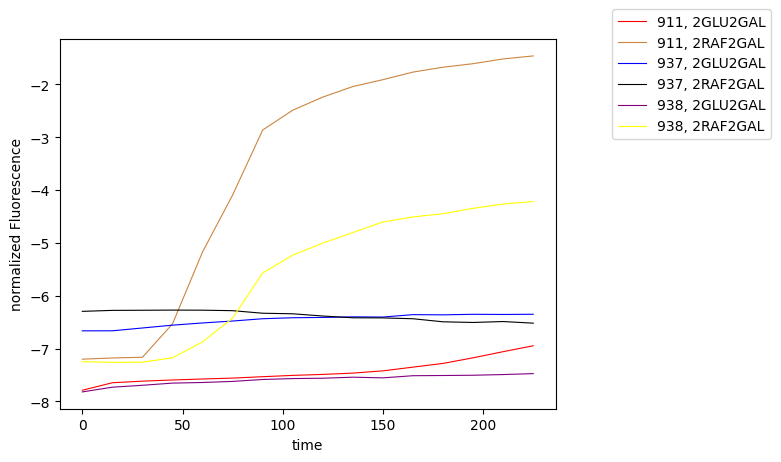

In [ ]:
# your code here
fig, ax = plt.subplots() #

#change the value inside the set_index function
means.set_index('time').plot(color=colors, ax=ax, linewidth=.8)

# Change to location of the legend. 
plt.legend(bbox_to_anchor=(1.1, 1.1), bbox_transform=ax.transAxes)
ax.set_ylabel('normalized Fluorescence')

#uncomment the line below to save the image
plt.savefig('flowcyto_over_time_02GAL_Red.png')

Describe what you see:

 - Are there differences between the three strains?
    
 - Are there differences between the conditions?
 

# distributions

in general, we are expecting log-normal distributions, so let's do a transformation on one of the strain + condition combinations which mean fluorescence seems to increase over time:

Let's first look at the strain / condition combination where something interesting seems to occur!

In [25]:
sel_strain='911' # fill in which strain you want to look at
sel_transition='2RAF2GAL' # fill in which condition you want to look at
sel_time = 0 # we will look at the first timepoint

In [26]:
df = comb_df[(comb_df["strain"]==sel_strain) & (comb_df['transition']==sel_transition)& (comb_df['time']==sel_time)
]
df

,FSC-H,FSC-A,SSC-H,SSC-A,GFP-488nm-H,GFP-488nm-A,Red-488nm-H,Red-488nm-A,CFP-405nm-H,CFP-405nm-A,...,RFP-561nm-H,RFP-561nm-A,FarRed-561nm-H,FarRed-561nm-A,FSC-Width,Time,strain,transition,time,FarRed_norm
850000,255113.9,313770.8,190328.4,200345.2,1465.2,1408.3,649.3,692.1,397.3,318.8,...,498.2,221.8,328.1,235.7,1259.4487,0.0,911,2RAF2GAL,0.0,0.000751
850001,162160.3,182856.2,131347.5,137061.9,969.4,838.7,435.9,469.4,375.8,38.7,...,547.0,101.7,255.4,157.0,1154.6869,123.0,911,2RAF2GAL,0.0,0.000859
850002,318208.8,392100.0,230301.9,253291.7,2083.6,2674.5,653.7,799.5,380.3,180.1,...,324.9,54.0,444.0,304.4,1261.7860,142.0,911,2RAF2GAL,0.0,0.000776
850003,218622.7,274652.6,168266.1,183528.9,1006.1,892.8,587.0,597.8,439.9,198.8,...,540.9,-209.6,255.0,92.8,1286.4756,192.0,911,2RAF2GAL,0.0,0.000338
850004,161587.6,167697.4,96423.4,96710.0,1031.5,1078.8,444.7,13.3,308.2,116.6,...,363.0,260.7,252.3,71.5,1062.7365,233.0,911,2RAF2GAL,0.0,0.000426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899995,234539.2,288753.0,194774.4,212774.8,1432.2,1315.2,619.6,447.7,251.1,8.8,...,505.2,180.6,338.8,261.9,1260.7151,1398358.0,911,2RAF2GAL,0.0,0.000907
899996,160712.0,189377.8,99520.4,102496.3,896.4,1048.0,436.7,-14.5,503.4,393.6,...,372.2,30.0,351.7,-62.5,1206.6465,1398394.0,911,2RAF2GAL,0.0,-0.000330
899997,248968.5,292709.6,151233.6,164480.6,1291.6,1400.1,580.4,655.7,393.7,311.7,...,336.8,-57.2,485.3,316.9,1203.9058,1398407.0,911,2RAF2GAL,0.0,0.001083
899998,161126.3,175566.0,108082.8,106958.2,1048.4,1086.2,659.8,516.8,463.0,67.7,...,715.8,251.1,380.6,134.0,1115.8118,1398436.0,911,2RAF2GAL,0.0,0.000763


/opt/miniconda3/envs/quant/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/quant/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 0, 'fluorescence (log)')

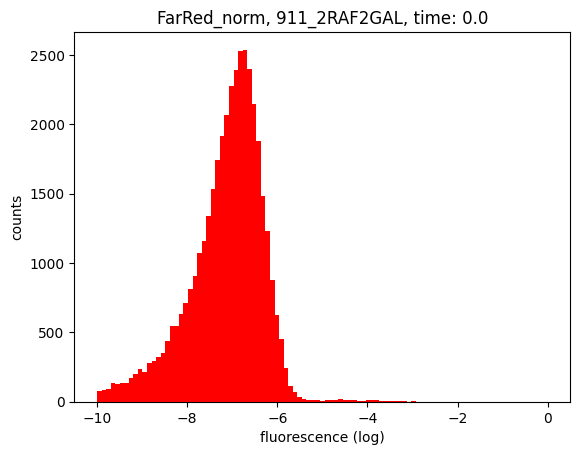

In [27]:
plt.hist(np.log(df[channel]), bins=np.linspace(-10,0, 100), color='red'); 
# np.linspace(0,15,100) gives us 100 evenly spaced values between 0 and 15
# Note it might be necesarry to change the values in linspace.

plt.title(f'{channel}, {df.strain.values[0]}_{df.transition.values[0]}, time: {df.time.values[0]}')
plt.ylabel('counts')
plt.xlabel('fluorescence (log)')

Now lets look at the next time point of this sample.

Text(0.5, 0, 'fluorescence (log)')

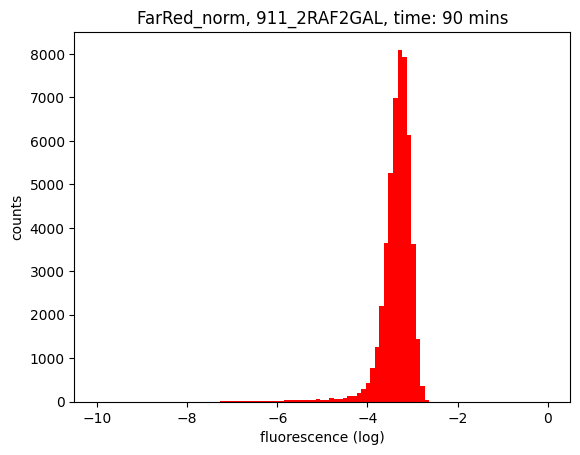

In [28]:
sel_time=90
df = comb_df[(comb_df["strain"]==sel_strain) & (comb_df['transition']==sel_transition)& (comb_df['time']==sel_time)
]

# let's now look at a later timepoint
plt.hist(np.log(df[channel]), bins=np.linspace(-10, 0, 100), color='red'); 
# np.linspace(0,15,100) gives us 100 evenly spaced values between 0 and 15
# Note it might be necesarry to change the values in linspace.

plt.title(f'{channel}, {sel_strain}_{sel_transition}, time: 90 mins')
plt.ylabel('counts')
plt.xlabel('fluorescence (log)')

Is the observed shift to be expected?

type you answer here.

Can this shift be observed in the other strains / conditions?

type you answer here.

# let's now look at all timepoints for these experiments together

Next we will use matplotlib subplots to plot all our time series data of the entire induction experiment. 
Multiplot subplots often involve nested for loops, which are complicated to understand. Take your time to understand what is happenning in the code below. Then try to interpret the resulting plots.

First, we will define a function to clean up our image labels and ticklabels.

In [29]:
def clean_up_mulitplot(axes,y,x):
    #cleaning up the figure
    #add title headings to the top of the column and remove ticklabels
    if y==0:
        axes[y,x].set_title(f'{strain}: {transition}')

    if x!=0:
        axes[y,x].set_yticklabels('')

    if y!=len(comb_df.time.unique())-1:
        axes[y,x].set_xticklabels('')

Next we will create our multiplot by iterating over the different condition, strain and time combinations.

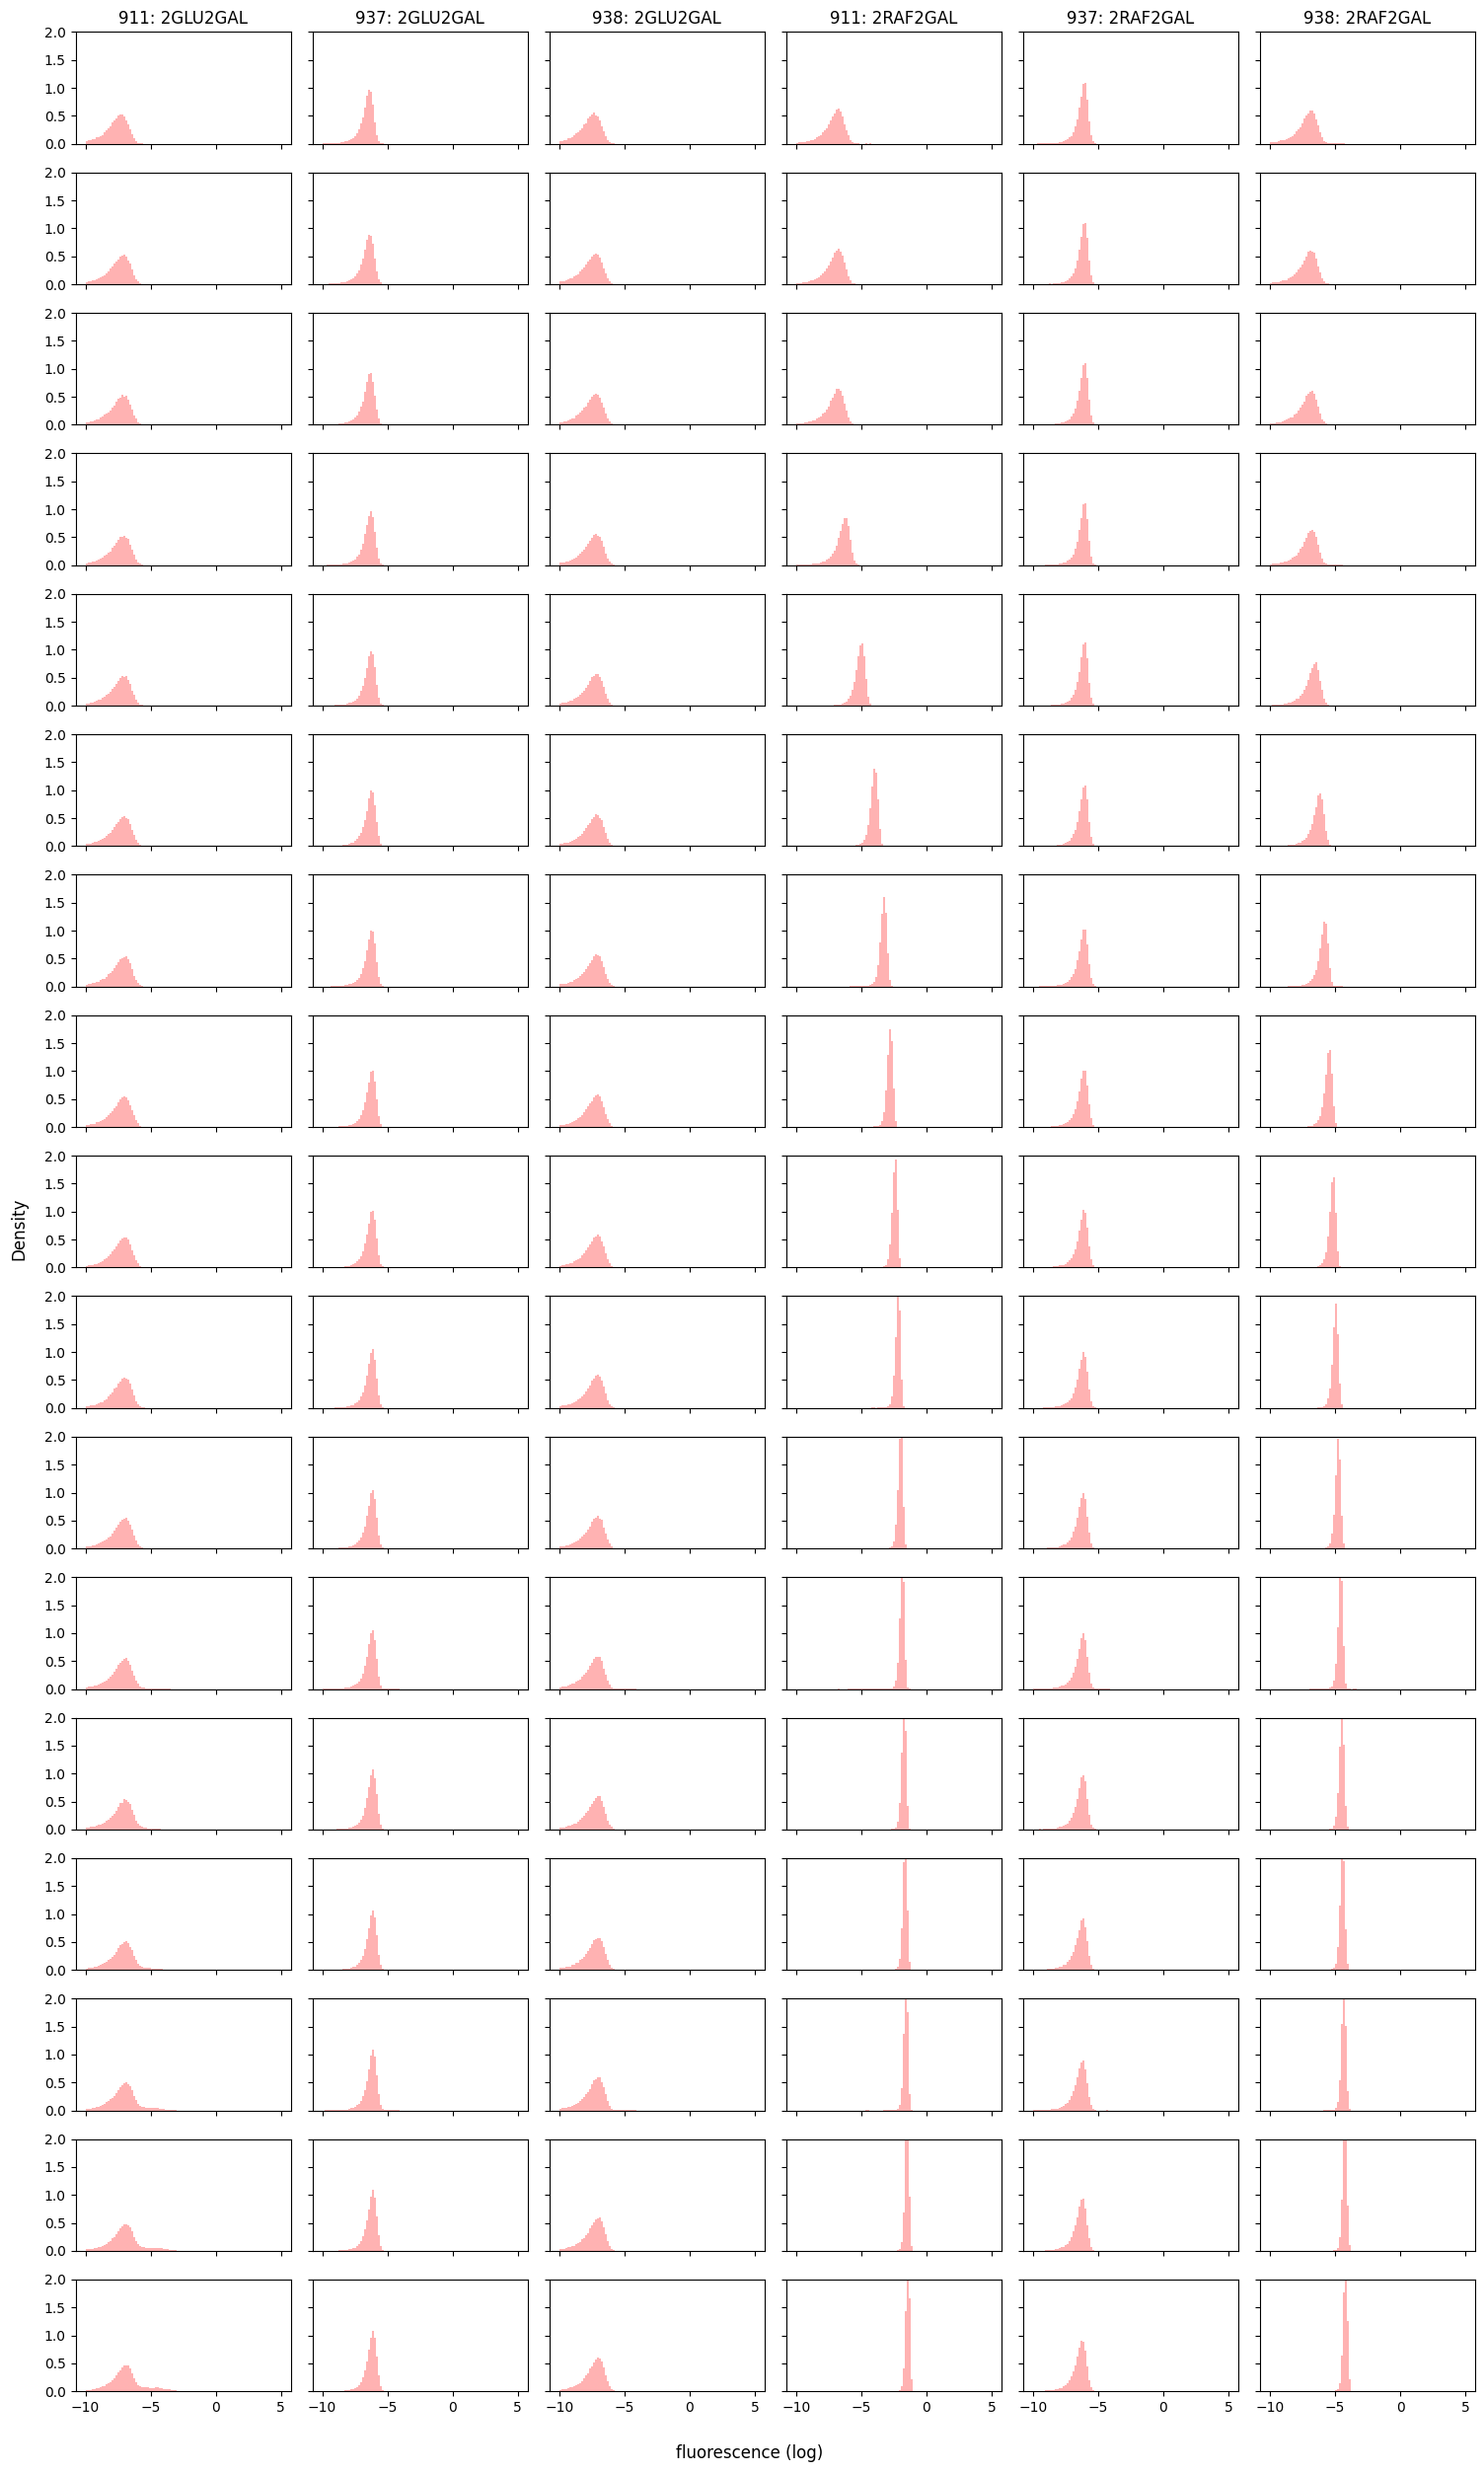

In [64]:
#create a grid
nrows=len(comb_df.time.unique())
#create a list with different time + strain combinations
transition_strain_combs=list(itertools.product(comb_df.transition.unique(),comb_df.strain.unique()))
#this is the different columns we need for our dataframe
ncols=len(transition_strain_combs)

# channel:
channel='FarRed_norm'

fig,axes=plt.subplots(nrows=nrows,ncols=ncols,figsize=(15,25), facecolor='white')

for (transition, strain),x in zip(transition_strain_combs,range(ncols)):
    
    df = comb_df[
        (comb_df['transition']==transition)
        & (comb_df['strain']==strain)
    ]
    
    for time,y in zip(sorted(comb_df.time.unique()),range(nrows)):
                      
        sT_df=df[df['time']==time]
        sT_df = sT_df[sT_df[channel]>0]
        
        #create the plot
        axes[y,x].hist(np.log(sT_df[channel]), bins=np.linspace(-10, 5, 100), alpha=0.3, density=True, color='red')
        
        #make sure the ylim is same for each plot
        axes[y,x].set_ylim(0,2)
        
        #call the image_clean_up function
        clean_up_mulitplot(axes,y,x)
        

            
#add one giant ylabel and xlabel
fig.supxlabel('fluorescence (log)',y=0.0)
fig.supylabel('Density', x=0.0)

plt.tight_layout()

#uncomment the following line to save your image
plt.savefig('Results/multiplot_induction_02_Red.png')

 - what can we conclude from the changes in the distributions over time?

Type your answer here.

####  your turn to code:

- Repeat the analysis for the other induction experiment dataset (hint look at the paths variable at the beginning of the notebook). 

- How do the morphological channels change over time?

Type your answer here.

# let's now look at all control experiment data and the additional timepoint measured after 16 hours of growth

Now let's look at our control experiments. These samples were either transitioned to galactose and measured after 16 hours or where not transitioned at all and measured.

### your turn:
What is the purpose of these different control strains?

your text here. 

In [33]:
path=Path('practical data','Full induction control_GLU or RAF to GALON_911_937_938').glob('*.csv')

files=sorted(path)
os.path.basename(files[1])

'858_2GLU2GAL.csv'

In [34]:
dfs=[]
    
for file in files:

    #get meta-data from filename for first two replicates
    #get meta-data from filename for two induction experiments
    strain, transition = Path(file).stem.split('_')

    #load data in pandas dataframe and add meta-data to frame
    df=pd.read_csv(file)
    df['strain']=strain
    df['transition']=transition
    df['time']=0
    dfs.append(df)

    dfs.append(df)
    
ctrl_df=pd.concat(dfs)
ctrl_df=pd.concat(dfs).reset_index(drop=True)
ctrl_df = ctrl_df[ctrl_df.columns[1:]]

# forward scatter correlates strongly with particle size. 
# to scale absolute fluorescence values to a concentration, divide each cell's fluorescence value
# by that cell's FSC value.
ctrl_df['FarRed_norm'] = ctrl_df['FarRed-561nm-A'] / ctrl_df['FSC-A']

### Now your turn to code!

- inspect the unique values contained in each column of the control dataframe.

In [45]:
#Code here
print("Transitions:")
print(f"{ctrl_df['transition'].unique()}")
print("Strains:")
print(f"{ctrl_df['strain'].unique()}")



Transitions:
['2GLU' '2GLU2GAL' '2RAF' '2RAF2GAL']
Strains:
['858' '911' '937' '938']


# Plot the control dataframe

In [40]:
nrows=len(ctrl_df.strain.unique())
ncols=len(ctrl_df.transition.unique())

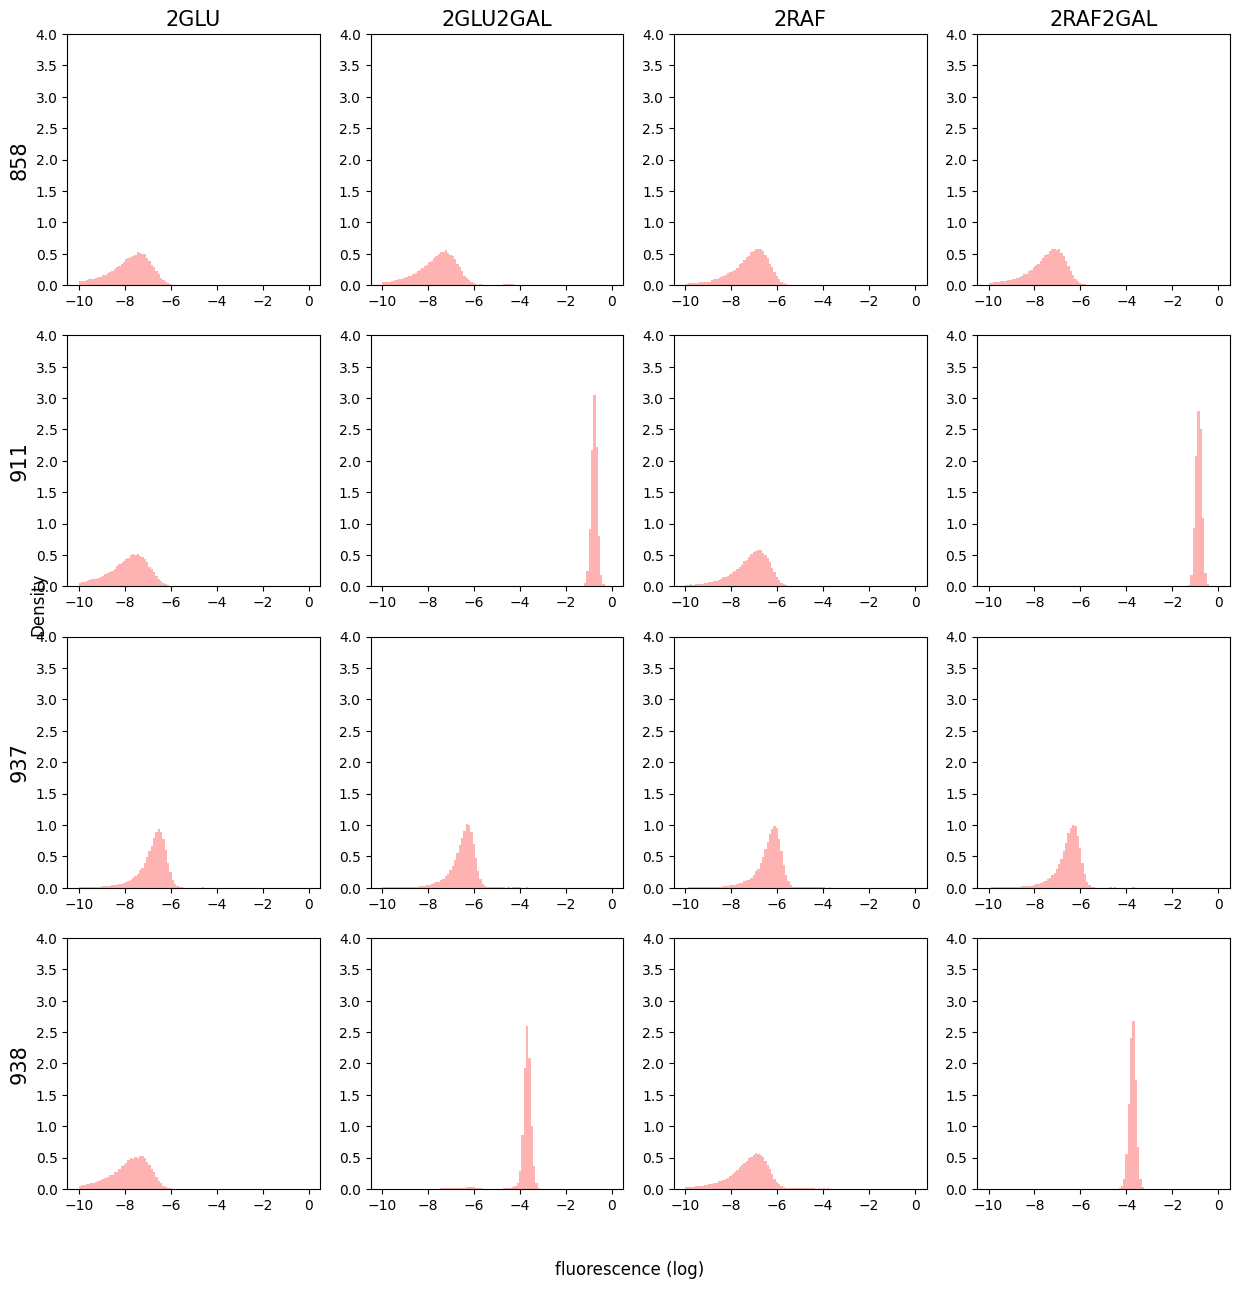

In [63]:
#create a grid
nrows=len(ctrl_df.strain.unique())
ncols=len(ctrl_df.transition.unique())

# channel:
channel='FarRed_norm'

fig,axes=plt.subplots(nrows=nrows,ncols=ncols,figsize=(15,15), facecolor='white')

for transition,x in zip(sorted(ctrl_df.transition.unique()),range(ncols)):
    
    for strain,y in zip(sorted(ctrl_df.strain.unique()),range(nrows)):
                      
        df = ctrl_df[
        (ctrl_df['transition']==transition)
        & (ctrl_df['strain']==strain)
        ]
        
        df = df[df[channel]>0]
        
        axes[y,x].hist(np.log(df[channel]), bins=np.linspace(-10, 0, 100), alpha=0.3, density=True, color='red')
        
        #make sure y range is the same for each plot
        axes[y,x].set_ylim(0,4)
        
        #add title headings to the top of the columns and each row.
        if y==0:
            axes[y,x].set_title(f'{transition}',size=15)
        if x==0:
            axes[y,x].set_ylabel(f'{strain}',size=15)
            
fig.supxlabel('fluorescence (log)',y=0.05)
fig.supylabel('Density', x=0.1)

#uncomment the following line to save your image
plt.savefig('multiplot_control.png')

### your turn:
- what can we learn from these control strains?

type your answer here.

- How do they compare to the other induction experiments?

type your answer here.

## your turn:

Can you recreate the multiplots above for the induction experiment but instead use scatterplot() function to plot FarRed-561nm-A vs. FSC-A. Make sure to log tranform both x and y variable.

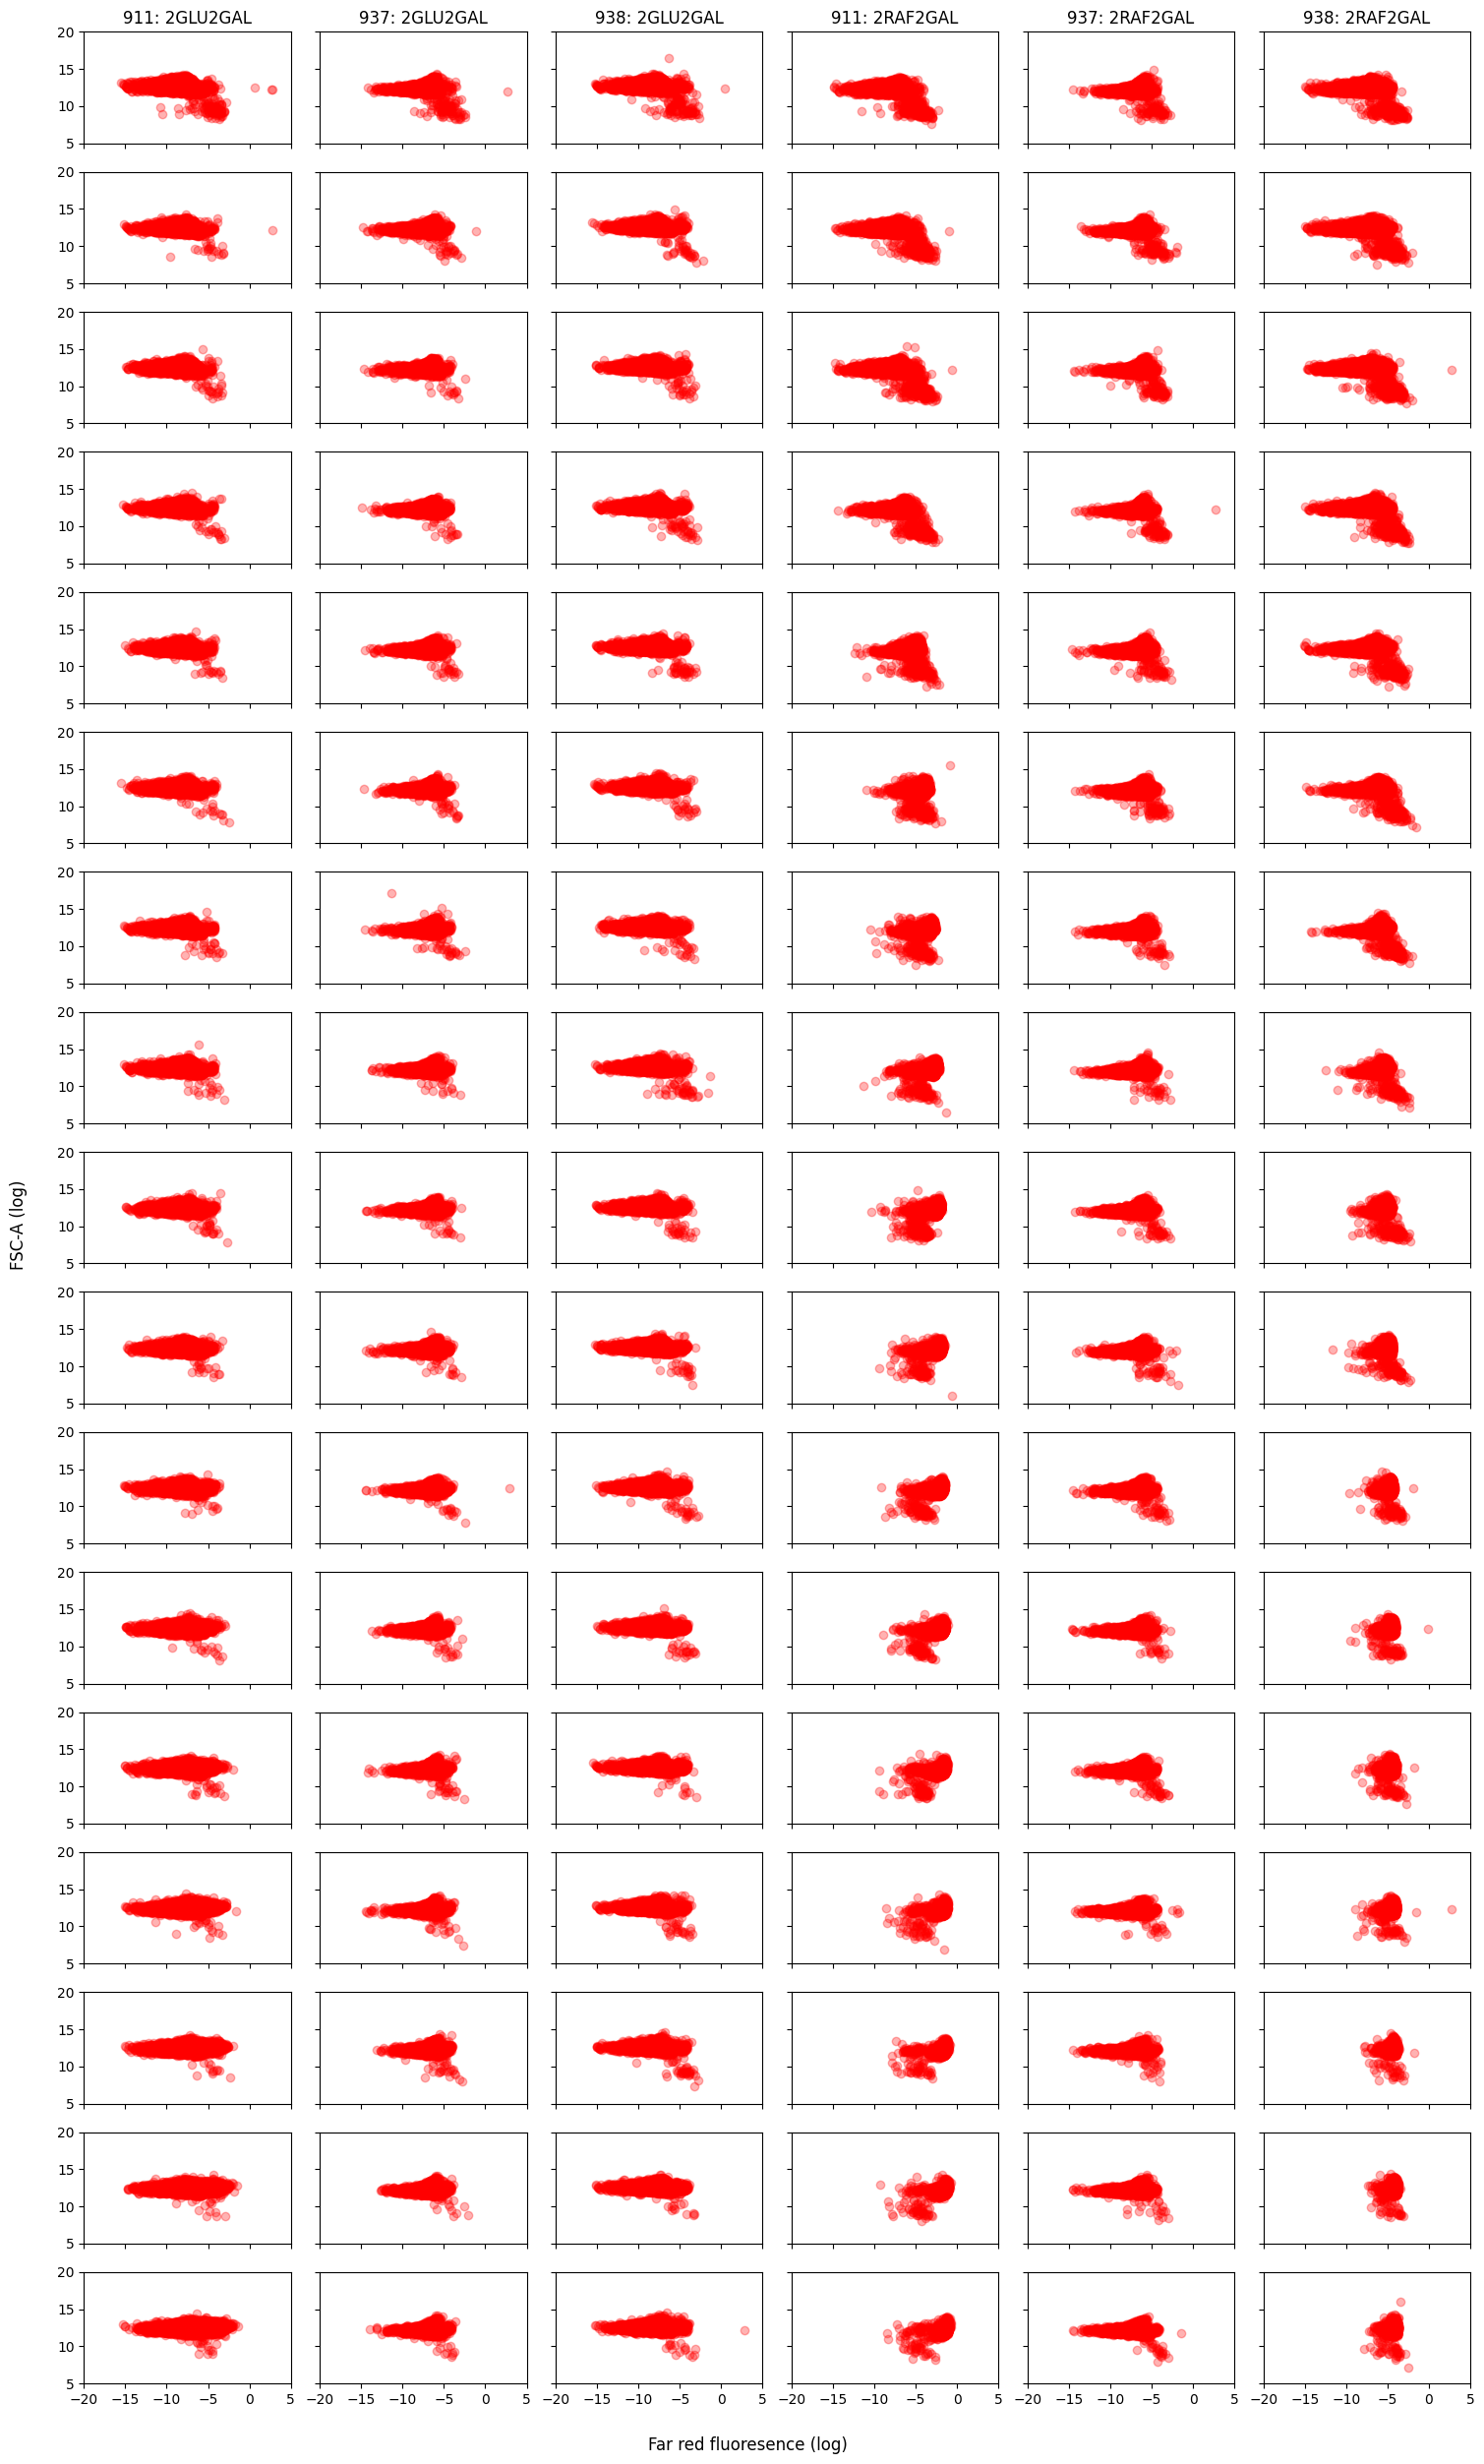

In [ ]:
#Code here
nrows=len(comb_df.time.unique())
#create a list with different time + strain combinations
transition_strain_combs=list(itertools.product(comb_df.transition.unique(),comb_df.strain.unique()))
#this is the different columns we need for our dataframe
ncols=len(transition_strain_combs)

# channel:
channel='FarRed_norm'

fig,axes=plt.subplots(nrows=nrows,ncols=ncols,figsize=(15,25), facecolor='white')

for (transition, strain),x in zip(transition_strain_combs,range(ncols)):
    
    df = comb_df[
        (comb_df['transition']==transition)
        & (comb_df['strain']==strain)
    ]
    
    for time,y in zip(sorted(comb_df.time.unique()),range(nrows)):
                      
        sT_df=df[df['time']==time]
        sT_df = sT_df[sT_df[channel]>0]
        
        #create the plot
        axes[y,x].scatter(np.log(sT_df[channel]),np.log(sT_df['FSC-A']), alpha=0.3, color='red')
        
        #make sure the ylim is same for each plot
        axes[y,x].set_ylim(5,20)
        axes[y,x].set_xlim(-20,5)
        #call the image_clean_up function
        clean_up_mulitplot(axes,y,x)
        

            
#add one giant ylabel and xlabel
fig.supxlabel('Far red fluoresence (log)',y=0.0)
fig.supylabel('FSC-A (log)', x=0.0)

plt.tight_layout()

#uncomment the following line to save your image
plt.savefig('Results/multiplot_scatter_induction_Red_FSC.png')

- What are we comparing in this plot?

write your answer here.

# Extra coding assignment

- Recreate the multiplots above using the seaborn plotting library instead

TypeError: ufunc 'log' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

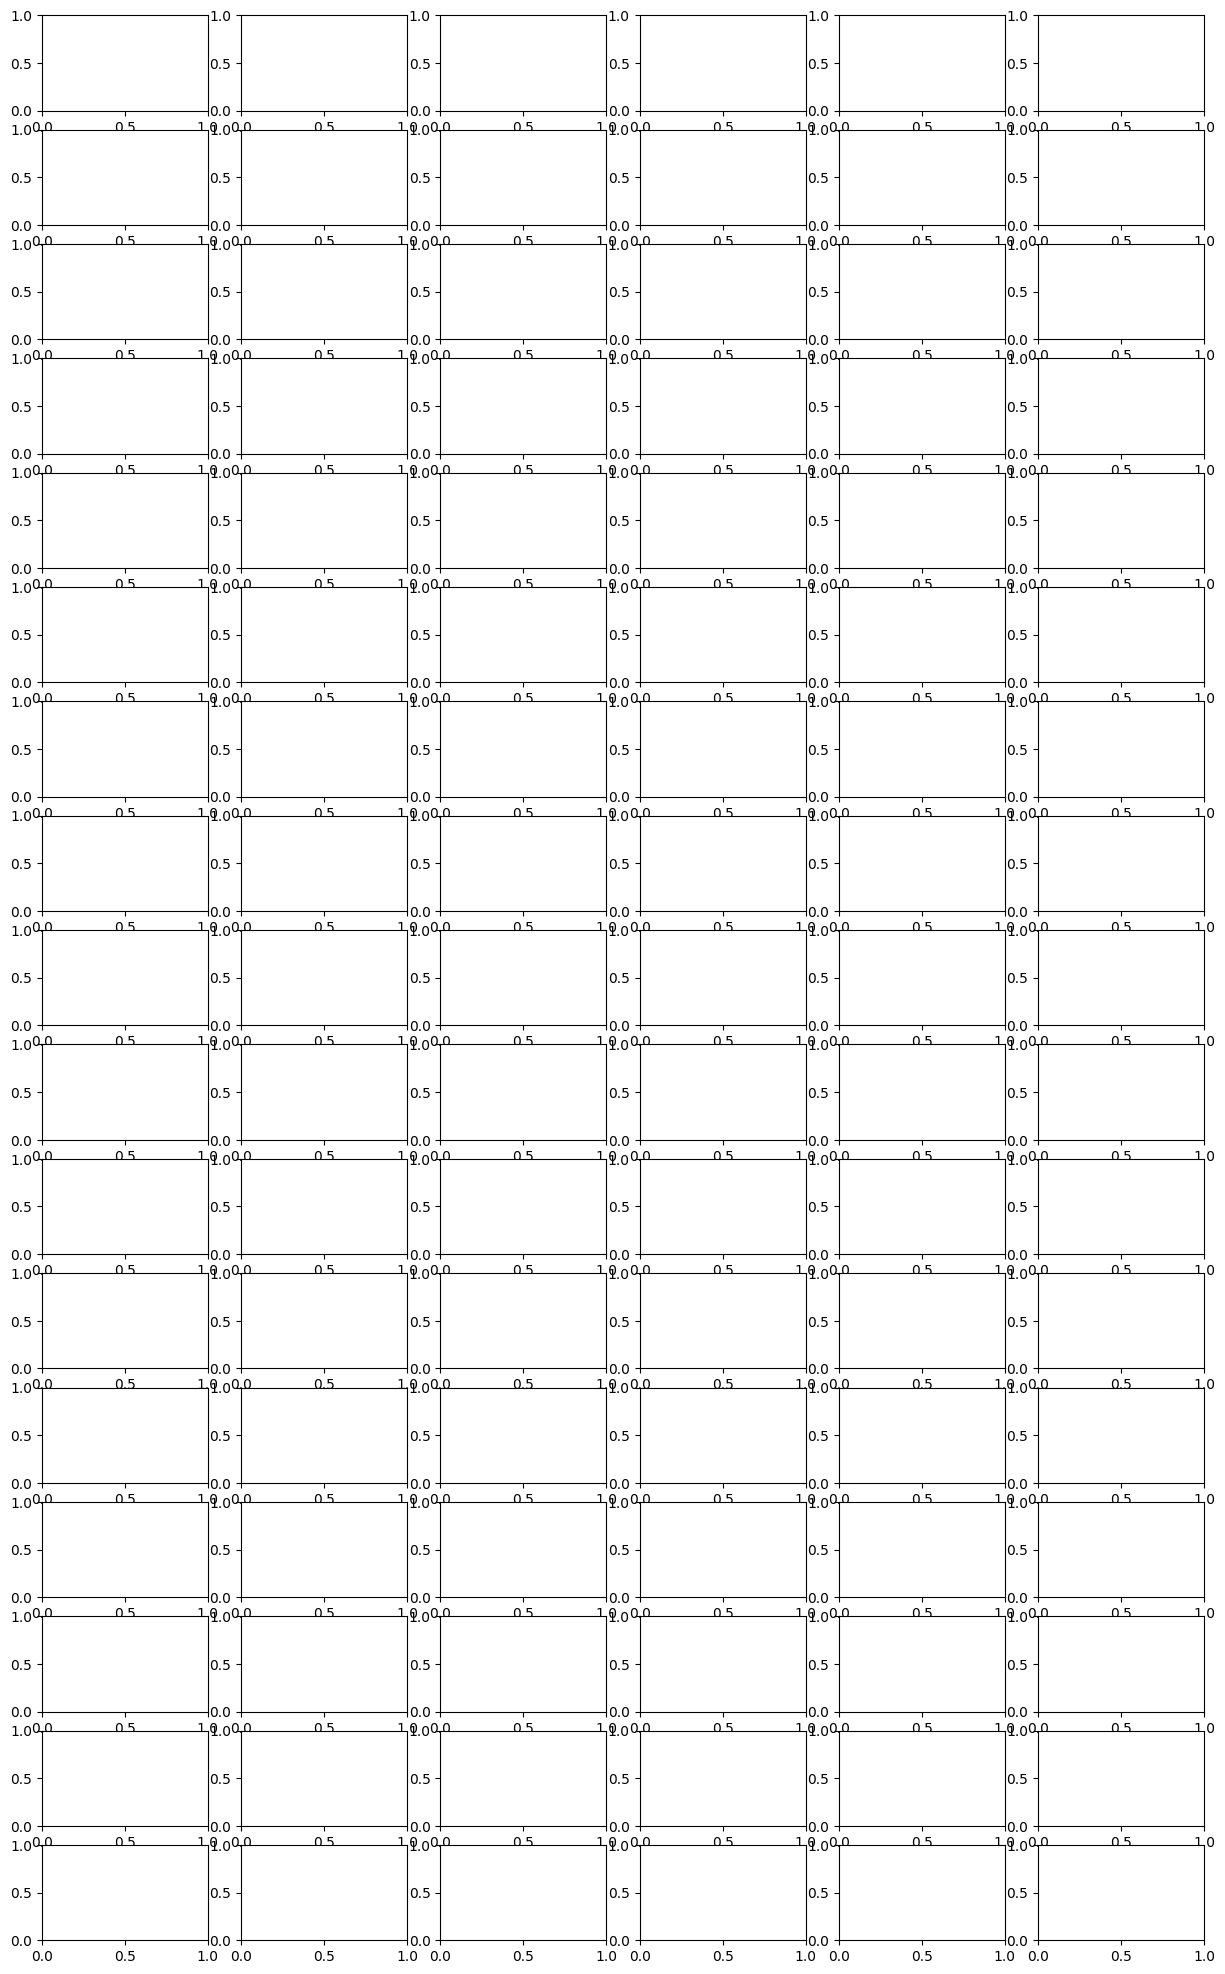

In [51]:
#Code here
#create a grid
nrows=len(comb_df.time.unique())
#create a list with different time + strain combinations
transition_strain_combs=list(itertools.product(comb_df.transition.unique(),comb_df.strain.unique()))
#this is the different columns we need for our dataframe
ncols=len(transition_strain_combs)

# channel:
channel='FarRed_norm'

fig,axes=plt.subplots(nrows=nrows,ncols=ncols,figsize=(15,25), facecolor='white')

for (transition, strain),x in zip(transition_strain_combs,range(ncols)):
    
    df = comb_df[
        (comb_df['transition']==transition)
        & (comb_df['strain']==strain)
    ]
    
    for time,y in zip(sorted(comb_df.time.unique()),range(nrows)):
                      
        sT_df=df[df['time']==time]
        sT_df = sT_df[sT_df[channel]>0]
        sT_df[f'log_{channel}']=np.log(channel)
        
        #create the plot
        sns.displot(data=sT_df, y=f"log_{channel}",ax=axes[y,x])
        
        #make sure the ylim is same for each plot
        axes[y,x].set_ylim(0,2)
        
        #call the image_clean_up function
        clean_up_mulitplot(axes,y,x)
        

            
#add one giant ylabel and xlabel
fig.supxlabel('fluorescence (log)',y=0.0)
fig.supylabel('Density', x=0.0)

plt.tight_layout()

#uncomment the following line to save your image
plt.savefig('Results/multiplot_induction_2_Red.png')

***

You finished the practical! Make sure to carefully interpret the results and save the resulting figures for your report.